[Open in Colab](https://colab.research.google.com/github/kurowskitomek/AircraftAccidents/blob/main/AircraftAccidents.ipynb)
# Analiza wpływu modelu samolotu na katastrofy lotnicze (1908–2019)
Notebook aktualizowany, aby spełniał wymagania projektu opisane w README.

In [678]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score
from sklearn.preprocessing import LabelEncoder
plt.style.use("seaborn-v0_8")


## Wczytanie danych
W tym projekcie wykorzystujemy otwarty zbiór danych Kaggle: "Airplane Crashes and Fatalities Since 1908".
Dane zostały pobrane lokalnie jako CSV i zawierają informacje o wypadkach lotniczych, liczbie osób na pokładzie, liczbie ofiar oraz opis przyczyny.
Technologie: Python, pandas, sklearn, seaborn, matplotlib.

Wczytanie zbioru danych lokalnie lub z Kaggle, jeżeli plik nie znajduje się w katalogu roboczym.

In [679]:
import glob
possible_files = glob.glob("Airplane_Crashes_and_Fatalities_Since_1908*.csv") + glob.glob("airplane-crashes-since-1908*.csv")
df = None
for filename in possible_files:
    if os.path.exists(filename):
        df = pd.read_csv(filename, low_memory=False, encoding="utf-8")
        print("Wczytano plik:", filename)
        break
if df is None:
    raise FileNotFoundError("Dataset nie został znaleziony lokalnie. Umieść plik CSV w katalogu roboczym.")
print("Wczytano wierszy:", len(df))
df.head()


Wczytano plik: Airplane_Crashes_and_Fatalities_Since_1908_20190820105639.csv
Wczytano wierszy: 4967


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,09/07/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,07/12/1912,06:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [680]:
# Zapewniamy istnienie kolumn czasowych i poprawne typy danych
# Jeżeli `Date` nie jest datetime, konwertujemy; tworzymy `Year` i `Decade` oraz `DecadeCategory`.
import pandas as pd
if 'Date' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
# Usuwamy wiersze bez poprawnej daty, bo dalej wiele analiz ich wymaga
if 'Date' in df.columns and df['Date'].isna().any():
    df = df[df['Date'].notna()].copy()
# Year
if 'Year' not in df.columns:
    if 'Date' in df.columns:
        df['Year'] = df['Date'].dt.year
    else:
        df['Year'] = pd.NA
# Ograniczenie zakresu danych do lat 1950-2019
if 'Year' in df.columns:
    df = df[df['Year'].between(1950, 2019)].copy()
    print('Zakres lat po filtrowaniu:', df['Year'].min(), '-', df['Year'].max(), 'wierszy:', len(df))
# Decade
if 'Decade' not in df.columns:
    try:
        df['Decade'] = (df['Year'] // 10) * 10
    except Exception:
        df['Decade'] = pd.NA
# DecadeCategory as string for grouping
if 'DecadeCategory' not in df.columns:
    df['DecadeCategory'] = df['Decade'].astype(str)
# Numeric conversions
for col in ['Aboard','Fatalities','FatalityRate']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
# Uogólnianie nazw typów samolotów
if 'AC Type' in df.columns:
    def normalize_ac_type(ac):
        if pd.isna(ac):
            return pd.NA
        ac_str = str(ac).strip()
        ac_upper = ac_str.upper()
        if 'BOEING' in ac_upper and '707' in ac_upper:
            return 'Boeing 707'
        if 'BOEING' in ac_upper and '717' in ac_upper:
            return 'Boeing 717'
        if 'BOEING' in ac_upper and '727' in ac_upper:
            return 'Boeing 727'
        if 'BOEING' in ac_upper and '737' in ac_upper:
            return 'Boeing 737'
        if 'BOEING' in ac_upper and '747' in ac_upper:
            return 'Boeing 747'
        if 'BOEING' in ac_upper and '767' in ac_upper:
            return 'Boeing 767'
        if 'BOEING' in ac_upper and '777' in ac_upper:
            return 'Boeing 777'
        if 'BOEING' in ac_upper and '787' in ac_upper:
            return 'Boeing 787'
        if 'AIRBUS' in ac_upper and '300' in ac_upper:
            return 'Airbus A300'
        if 'AIRBUS' in ac_upper and '310' in ac_upper:
            return 'Airbus A310'
        if 'AIRBUS' in ac_upper and '320' in ac_upper or 'AIRBUS' in ac_upper and '318' in ac_upper or 'AIRBUS' in ac_upper and '319' in ac_upper or 'AIRBUS' in ac_upper and '321' in ac_upper:
            return 'Airbus A320'
        if 'AIRBUS' in ac_upper and '330' in ac_upper:
            return 'Airbus A330'
        if 'AIRBUS' in ac_upper and '340' in ac_upper:
            return 'Airbus A340'
        if 'AIRBUS' in ac_upper and '350' in ac_upper:
            return 'Airbus A350'
        if 'DOUGLAS' in ac_upper and 'DC-3' in ac_upper or 'DOUGLAS' in ac_upper and '47' in ac_upper:
            return 'Douglas DC-3'
        if 'DOUGLAS' in ac_upper and 'DC-4' in ac_upper:
            return 'Douglas DC-4'
        if 'DOUGLAS' in ac_upper and 'DC-6' in ac_upper:
            return 'Douglas DC-6'
        if 'DOUGLAS' in ac_upper and 'DC-8' in ac_upper:
            return 'Douglas DC-8'
        if 'DOUGLAS' in ac_upper and 'DC-9' in ac_upper:
            return 'McDonnell Douglas DC-9'
        if 'MD-80' in ac_upper or 'MD 80' in ac_upper or 'MD-81' in ac_upper or 'MD 81' in ac_upper or 'MD-82' in ac_upper or 'MD 82' in ac_upper or 'MD-83' in ac_upper or 'MD 83' in ac_upper or 'MD-88' in ac_upper or 'MD 88' in ac_upper or 'MD-87' in ac_upper or 'MD 87' in ac_upper:
            return 'McDonnell Douglas MD-80'
        if 'DC-10' in ac_upper:
            return 'McDonnell Douglas DC-10'
        if 'MD-11' in ac_upper:
            return 'McDonnell Douglas MD-11'
        if 'IL-18' in ac_upper or 'IL 18' in ac_upper:
            return 'Ilyushin IL-18'
        if 'TU-134' in ac_upper or 'TU134' in ac_upper:
            return 'Tupolev TU-134'
        if 'TU-154' in ac_upper or 'TU154' in ac_upper:
            return 'Tupolev TU-154'
        return ac_str
    df['AC Type'] = df['AC Type'].apply(normalize_ac_type)
# Ograniczenie do zdarzeń z co najmniej 40 osobami na pokładzie
if 'Aboard' in df.columns:
    df = df[df['Aboard'] >= 40].copy()
    print('Zdarzenia z co najmniej 40 osobami na pokładzie:', len(df))
# Informacja zwrotna
print('Aktualne kolumny w df:', list(df.columns))


Zakres lat po filtrowaniu: 1950 - 2019 wierszy: 3817
Zdarzenia z co najmniej 40 osobami na pokładzie: 1037
Aktualne kolumny w df: ['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'AC Type', 'Registration', 'cn/ln', 'Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground', 'Summary', 'Year', 'Decade', 'DecadeCategory']


## Czyszczenie i przygotowanie danych
Usuwamy duplikaty, konwertujemy zmienne, ograniczamy okres 1908-2019 oraz tworzymy nowe wskaźniki.

In [681]:
# Pokazujemy kilka pierwszych wierszy z przyjaznymi, polskimi etykietami kolumn.
display_df = df.rename(columns={
    'AC Type': 'Typ samolotu',
    'Aboard': 'Liczba na pokładzie',
    'Fatalities': 'Liczba ofiar',
    'FatalityRate': 'Odsetek ofiar (%)',
    'Date': 'Data',
    'Year': 'Rok',
    'Decade': 'Dekada'
})
print('Tabela — przykładowe wiersze: kolumny przetłumaczone na polski; format: Data, Rok, Dekada, Typ samolotu, Liczba na pokładzie, Liczba ofiar, Odsetek ofiar (%)')
display(display_df.head())


Tabela — przykładowe wiersze: kolumny przetłumaczone na polski; format: Data, Rok, Dekada, Typ samolotu, Liczba na pokładzie, Liczba ofiar, Odsetek ofiar (%)


,Data,Time,Location,Operator,Flight #,Route,Typ samolotu,Registration,cn/ln,Liczba na pokładzie,Aboard Passangers,Aboard Crew,Liczba ofiar,Fatalities Passangers,Fatalities Crew,Ground,Summary,Rok,Dekada,DecadeCategory
1155,1950-01-26,NaN,"Near Snag, Yukon Territory",Military - U.S. Air Force,NaN,"Elmendorf - Great Falls, MT",Douglas DC-4,42-72469,10574,44.0,36.0,8.0,44.0,36.0,8.0,0.0,"Operated by the Strategic Air Command, the tra...",1950,1950,1950
1160,1950-03-12,14:50,"Llandow Airport, Cardiff, Wales",Fairflight Ltd.,NaN,Llandow - Dublin,Avro 689 Tudor 5,G-AKBY,1417,83.0,78.0,5.0,80.0,75.0,5.0,0.0,During the approach to Runway 28 at Llandow Ai...,1950,1950,1950
1173,1950-06-05,22:03,Atlantic Ocean off Florida,Westair Transport,NaN,San Juan - Wilmington NC,Curtiss C-46-F-1-CU,N1248N,22496,65.0,62.0,3.0,28.0,28.0,0.0,0.0,Ditched into the Atlantic 300 miles east of Me...,1950,1950,1950
1175,1950-06-12,21:52,Off Bahrain,Air France,NaN,Saigon - Paris,Douglas DC-4,F-BBDE,42937,52.0,44.0,8.0,46.0,40.0,6.0,0.0,"While making a final approach for Bahrain, the...",1950,1950,1950
1176,1950-06-14,21:55,Off Bahrain,Air France,NaN,Saigon - Paris,Douglas DC-4,F-BBDM,42990,53.0,45.0,8.0,40.0,37.0,3.0,0.0,The aircraft crashed into the Persian Gulf whi...,1950,1950,1950


## Selekcja modeli AC Type
Wybieramy rodziny i modele występujące co najmniej 12 razy lub maksymalnie 20 najczęściej występujących. Dodatkowo uwzględniamy kluczowe rodziny Airbusa i Boeinga, aby nie pominąć ważnych grup takich jak Airbus A320 family.

In [682]:
ac_counts = df["AC Type"].value_counts()
selected_types = ac_counts[ac_counts >= 5].index.tolist()
important_families = [
    #"Airbus A320",
    #"Airbus A330",
    #"Airbus A340",
    #"Airbus A350",
    #"Boeing 737",
    #"Boeing 747",
    #"Boeing 767",
    #"Boeing 777",
    #"Boeing 787",
]
for fam in important_families:
    if fam in ac_counts.index and fam not in selected_types:
        selected_types.append(fam)

# Gwarantujemy, że ważne rodziny pozostaną w podsumowaniu nawet przy ograniczeniu do 20 najczęściej występujących typów.
if len(selected_types) > 20:
    base_types = [t for t in selected_types if t in important_families]
    extra_types = [t for t in ac_counts.index if t not in important_families and t in selected_types]
    selected_types = base_types + extra_types[: max(0, 20 - len(base_types))]

print("Liczba wybranych modeli:", len(selected_types))
display(ac_counts.loc[selected_types])
df = df[df["AC Type"].isin(selected_types)].copy()
print("Wiersze po wyborze modeli:", len(df))


Liczba wybranych modeli: 20


AC Type
Boeing 737                     82
Boeing 727                     51
Boeing 707                     41
McDonnell Douglas DC-9         34
Ilyushin IL-18                 32
Tupolev TU-154                 29
Douglas DC-8                   27
Douglas DC-6                   26
Boeing 747                     26
Tupolev TU-134                 22
McDonnell Douglas MD-80        18
Douglas DC-4                   17
McDonnell Douglas DC-10        16
Airbus A320                    16
Antonov AN-24                  12
Antonov AN-26                  12
Airbus A300                    11
Fokker F-28 Fellowship 1000    10
Lockheed C-130H                 9
Antonov AN-24B                  8
Name: count, dtype: int64

Wiersze po wyborze modeli: 499


## Kategoryzacja przyczyn katastrof
Tworzymy zmienną CauseCategory na podstawie opisu Summary.

In [683]:
def categorize_cause(summary):
    if pd.isna(summary):
        return "Unknown"
    text = str(summary).lower()
    if any(keyword in text for keyword in ["hijack", "terror", "bomb", "attack", "gun", "shot", "suicide"]):
        return "Terroryzm i porwania"
    if "cfit" in text or "controlled flight" in text or "controlled into terrain" in text:
        return "CFIT"
    if any(keyword in text for keyword in ["mid-air", "mid air", "collision", "collided"]):
        return "Zderzenie w powietrzu"
    if any(keyword in text for keyword in ["pilot error", "pilot", "crew error", "crew", "stalled", "takeoff", "landing", "approach", "runway", "taxi", "control"]):
        return "Błąd pilota"
    if any(keyword in text for keyword in ["engine", "mechanical", "failure", "fire", "fault", "maintenance", "structural", "landing gear", "flap", "hydraulic", "fuel"]):
        return "Usterka mechaniczna"
    if any(keyword in text for keyword in ["weather", "storm", "fog", "ice", "hail", "wind", "snow", "cloud", "visibility", "turbulence", "lightning"]):
        return "Pogoda"
    if any(keyword in text for keyword in ["unknown", "undetermined", "not determined", "no cause", "unable to determine"]):
        return "Nieznane"
    return "Inne"
df["CauseCategory"] = df["Summary"].apply(categorize_cause)
print(df["CauseCategory"].value_counts())


CauseCategory
Błąd pilota              335
Terroryzm i porwania      70
Zderzenie w powietrzu     37
Usterka mechaniczna       27
Inne                      12
Pogoda                    10
Nieznane                   4
CFIT                       4
Name: count, dtype: int64


In [684]:

top15_models = df['AC Type'].value_counts().head(15).index

df = df[df['AC Type'].isin(top15_models)].copy()

print(f"Liczba rekordów po filtrowaniu: {len(df)}")
print("\nAnalizowane modele:")
print(df['AC Type'].value_counts())

Liczba rekordów po filtrowaniu: 449

Analizowane modele:
AC Type
Boeing 737                 82
Boeing 727                 51
Boeing 707                 41
McDonnell Douglas DC-9     34
Ilyushin IL-18             32
Tupolev TU-154             29
Douglas DC-8               27
Douglas DC-6               26
Boeing 747                 26
Tupolev TU-134             22
McDonnell Douglas MD-80    18
Douglas DC-4               17
McDonnell Douglas DC-10    16
Airbus A320                16
Antonov AN-24              12
Name: count, dtype: int64


## Analiza zmiennych i hipotezy
Wybieramy trzy hipotezy badawcze zgodne z celem projektu:

- H1: Model samolotu ma istotny wpływ na procent ofiar śmiertelnych w katastrofie.
- H2: Dominująca przyczyna katastrofy zależy od modelu samolotu.
- H3: Wpływ modelu samolotu na śmiertelność katastrof zmieniał się w czasie.

Każdą hipotezę analizujemy w oddzielnej sekcji.


In [685]:
# Przygotowanie dodatkowych zmiennych pomocniczych do analizy
# Zmienna jakościowa dla roku i liczby osób na pokładzie
if 'DecadeCategory' not in df.columns:
    df['DecadeCategory'] = df.get('Decade', pd.Series(pd.NA, index=df.index)).astype(str)

# Upewniamy się, że kolumny numeryczne istnieją i mają poprawny typ
for col in ['Aboard','Fatalities']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Obliczamy FatalityRate jeśli jeszcze nie istnieje
if 'FatalityRate' not in df.columns or df['FatalityRate'].isna().all():
    if 'Fatalities' in df.columns and 'Aboard' in df.columns:
        # unikamy dzielenia przez zero
        df['FatalityRate'] = (df['Fatalities'] / df['Aboard'].replace({0: pd.NA})) * 100
    else:
        df['FatalityRate'] = pd.NA

# Grupy liczby osób na pokładzie
if 'Aboard' in df.columns:
    df['AboardGroup'] = pd.cut(
        df['Aboard'],
        bins=[30, 60, 120, 250, 1000],
        labels=['31-60','61-120','121-250','>250']
    )
else:
    df['AboardGroup'] = pd.NA

# Grupy odsetka ofiar - bezpiecznie używamy pd.cut na istniejącej serii
if 'FatalityRate' in df.columns:
    df['FatalityRateGroup'] = pd.cut(
        df['FatalityRate'].fillna(-1),
        bins=[-1, 0, 20, 40, 60, 80, 100],
        labels=['0','1-20','21-40','41-60','61-80','81-100']
    )
else:
    df['FatalityRateGroup'] = pd.NA

# Sprawdzenie, ile wierszy zostało po filtrowaniu i przygotowaniu danych
print('Rozmiar zbioru po przygotowaniu:', len(df))
print('Unikalne wartości CauseCategory:', df['CauseCategory'].nunique())
print('Przykładowe grupy AboardGroup:', df['AboardGroup'].value_counts().to_dict())


Rozmiar zbioru po przygotowaniu: 449
Unikalne wartości CauseCategory: 8
Przykładowe grupy AboardGroup: {'61-120': 213, '121-250': 129, '31-60': 80, '>250': 27}


### H1: Model a procent ofiar śmiertelnych
W tej sekcji analizujemy, czy `FatalityRate` różni się w zależności od modelu samolotu oraz czy relacja ta jest powiązana z dekadą i kategorią przyczyny.

Zmienne użyte w H1:
- `AC Type` (model samolotu) — zmienna jakościowa
- `FatalityRate` — główna zmienna ilościowa opisująca procent ofiar śmiertelnych
- `Aboard`, `Fatalities` — zmienne ilościowe, które mogą wpływać na poziom śmiertelności
- `DecadeCategory`, `CauseCategory`, `AboardGroup`, `FatalityRateGroup` — zmienne pomocnicze do analizy kontekstu


In [686]:
quantitative = ['Aboard', 'Fatalities', 'FatalityRate']
stats = df[quantitative].agg(['count', 'mean', 'median', 'min', 'max', 'std', 'var']).T
stats['mode'] = [df[col].mode().iloc[0] if not df[col].mode().empty else pd.NA for col in quantitative]
display(stats)

categorical = ['AC Type', 'CauseCategory', 'DecadeCategory', 'FatalityRateGroup']
for col in categorical:
    # Przedstawiamy rozkład kategorii
    if col == 'AC Type':
        print('### Typ samolotu — rozkład i liczności')
        display(df[col].value_counts().rename_axis('Typ samolotu').to_frame('Liczba wystąpień'))
    elif col == 'CauseCategory':
        print('### Kategoria przyczyny — opis i liczności')
        display(df[col].value_counts().rename_axis('Kategoria przyczyny').to_frame('Liczba wypadków'))
    elif col == 'DecadeCategory':
        print('### Dekada — rozkład zdarzeń')
        display(df[col].value_counts().sort_index().rename_axis('Dekada').to_frame('Liczba wypadków'))
    elif col == 'FatalityRateGroup':
        print('### Kategorie odsetka ofiar (%)')
        display(df[col].value_counts().rename_axis('Kategoria odsetka ofiar').to_frame('Liczba wypadków'))


,count,mean,median,min,max,std,var,mode
Aboard,449.0,116.276169,102.000000,40.0,644.0,72.906706,5315.387846,52.0
Fatalities,449.0,73.220490,61.000000,0.0,583.0,68.946103,4753.565115,0.0
FatalityRate,449.0,67.014024,92.857143,0.0,100.0,40.232554,1618.658367,100.0


### Typ samolotu — rozkład i liczności


,Liczba wystąpień
Typ samolotu,
Boeing 737,82
Boeing 727,51
Boeing 707,41
McDonnell Douglas DC-9,34
Ilyushin IL-18,32
Tupolev TU-154,29
Douglas DC-8,27
Douglas DC-6,26
Boeing 747,26


### Kategoria przyczyny — opis i liczności


,Liczba wypadków
Kategoria przyczyny,
Błąd pilota,302
Terroryzm i porwania,59
Zderzenie w powietrzu,36
Usterka mechaniczna,26
Inne,10
Pogoda,8
Nieznane,4
CFIT,4


### Dekada — rozkład zdarzeń


,Liczba wypadków
Dekada,
1950,24
1960,75
1970,101
1980,99
1990,74
2000,51
2010,25


### Kategorie odsetka ofiar (%)


,Liczba wypadków
Kategoria odsetka ofiar,
81-100,259
1-20,87
61-80,32
41-60,25
21-40,24
0,22


### H1: Wizualizacja `FatalityRate`
Wizualizujemy rozkład `FatalityRate` oraz zależności od kategorii przyczyny i grup liczby osób na pokładzie.


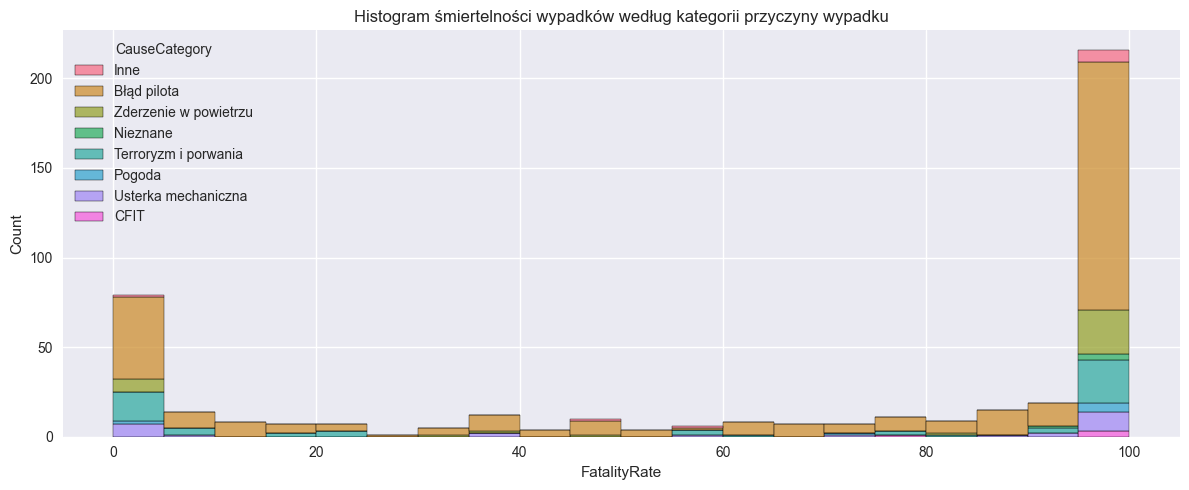

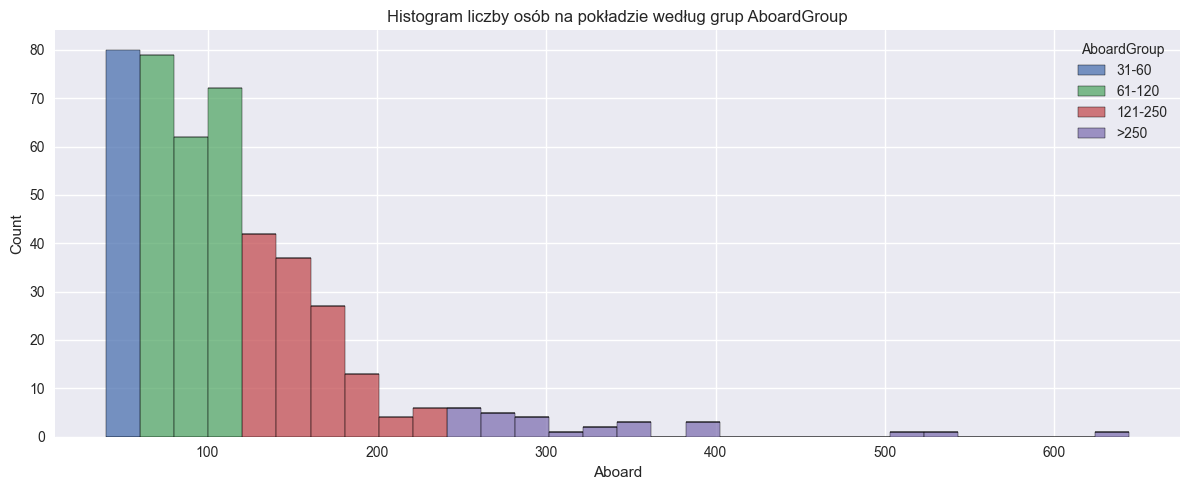

C:\Users\tomek\AppData\Local\Temp\ipykernel_29168\3171805555.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(data=df, x='CauseCategory', y='FatalityRate', hue='AboardGroup', dodge=True, estimator='mean', ci=None)


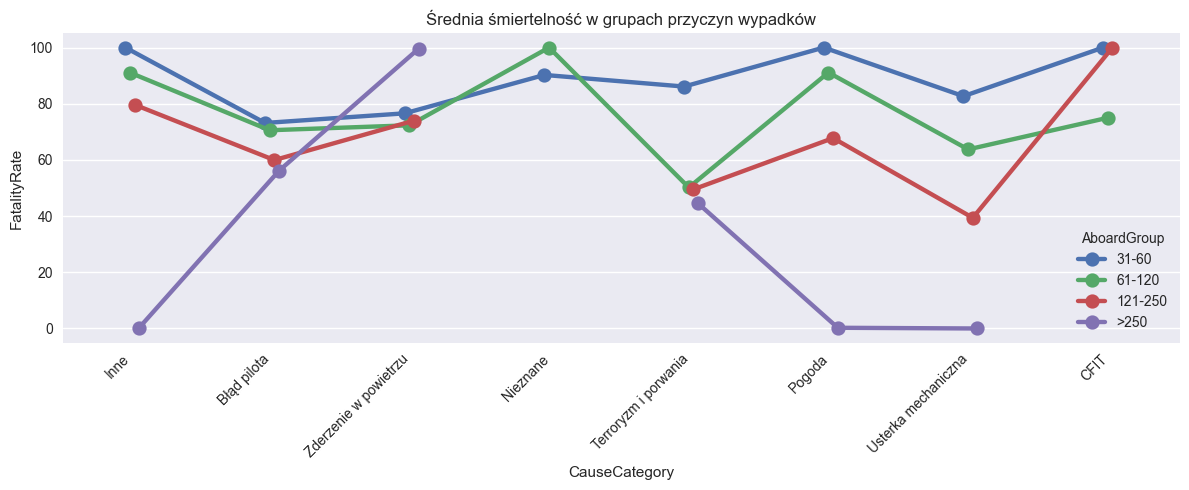

C:\Users\tomek\AppData\Local\Temp\ipykernel_29168\3171805555.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['AC Type'].isin(top_types)], x='FatalityRate', y='AC Type', order=top_types, palette='coolwarm')


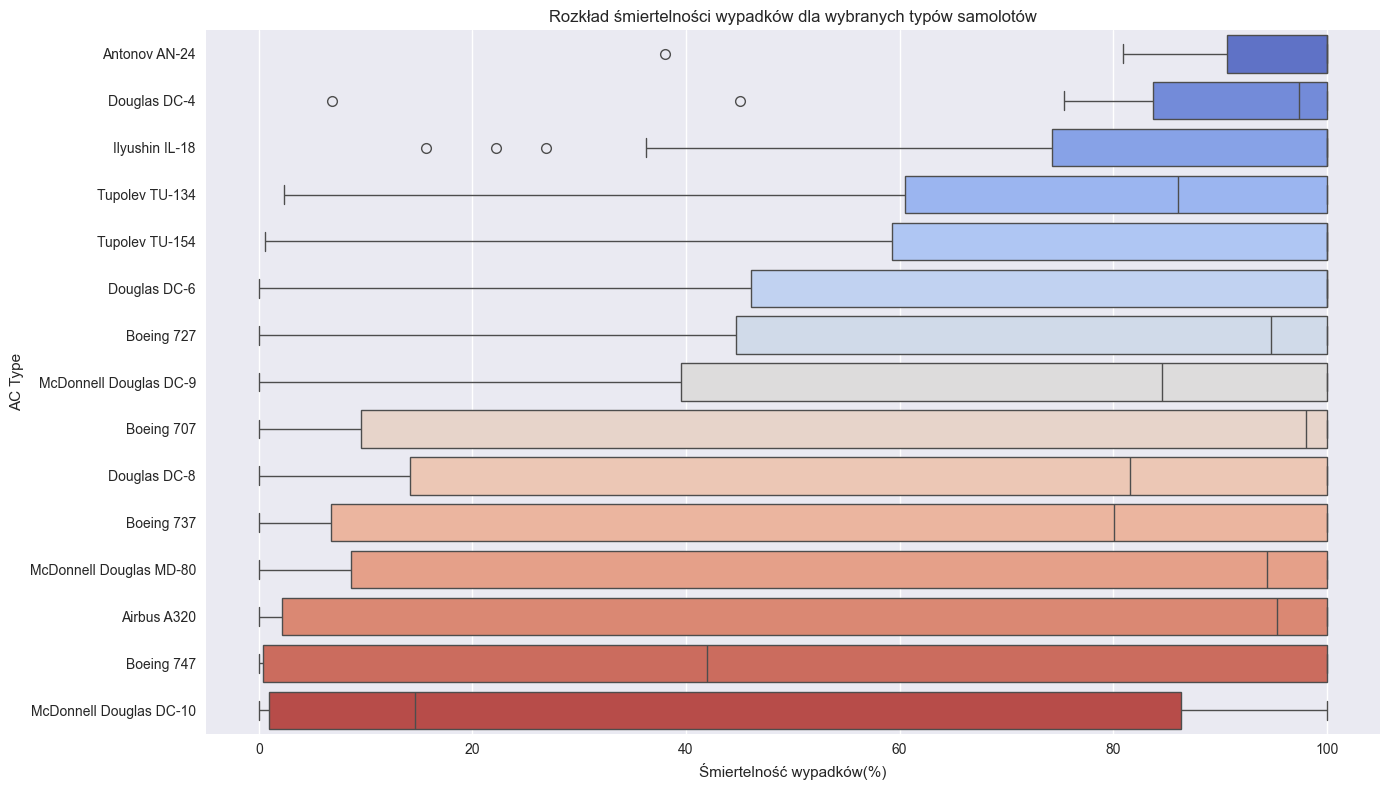

C:\Users\tomek\AppData\Local\Temp\ipykernel_29168\3171805555.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_stats, x='mean', y='AC Type', palette='viridis')


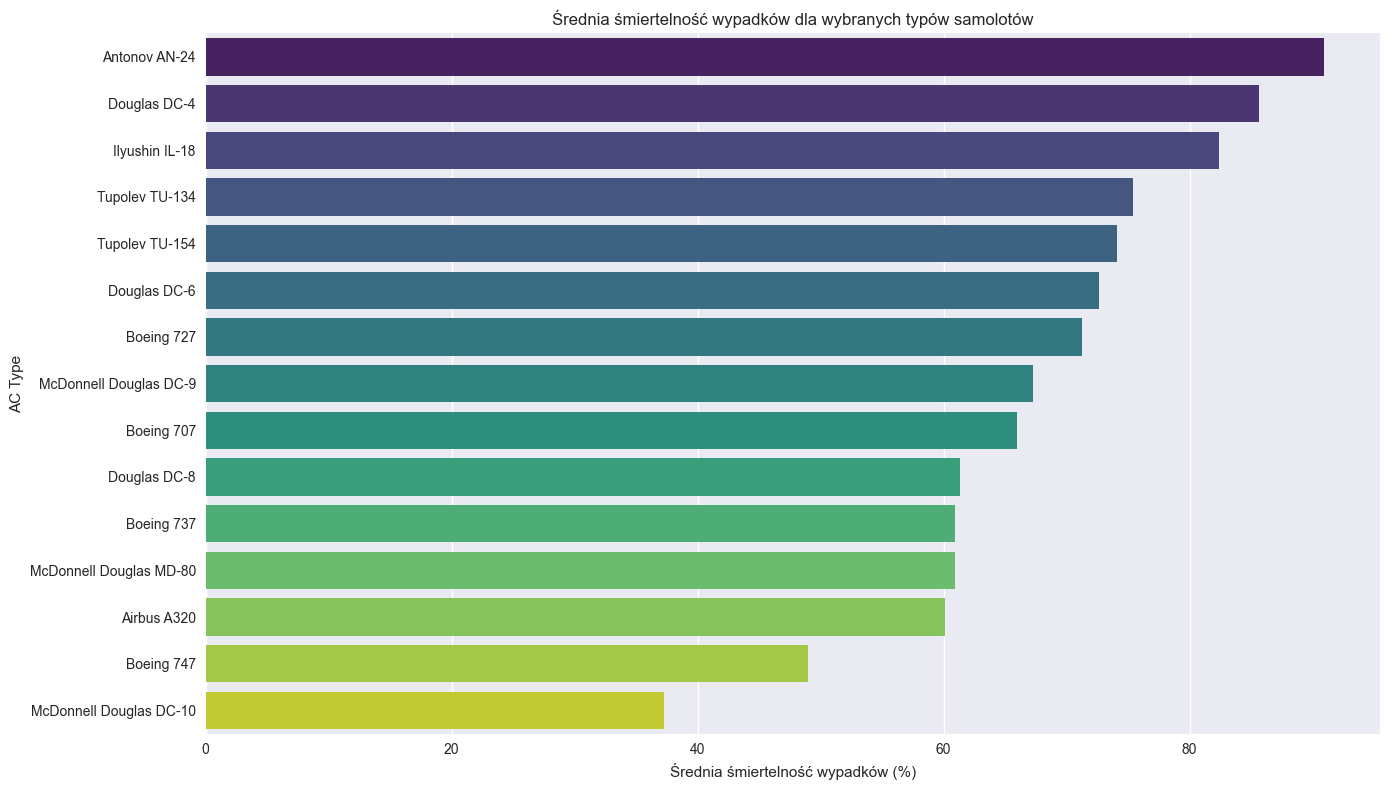

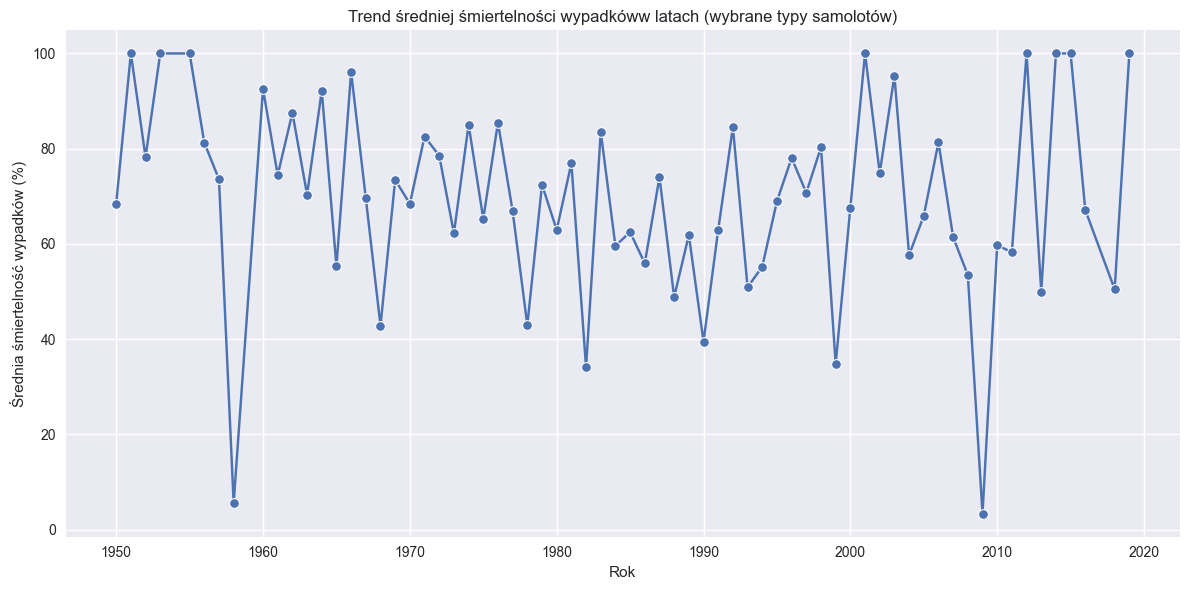

In [687]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='FatalityRate', hue='CauseCategory', multiple='stack', bins=20)
plt.title('Histogram śmiertelności wypadków według kategorii przyczyny wypadku')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(data=df, x='Aboard', hue='AboardGroup', bins=30, multiple='stack')
plt.title('Histogram liczby osób na pokładzie według grup AboardGroup')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.pointplot(data=df, x='CauseCategory', y='FatalityRate', hue='AboardGroup', dodge=True, estimator='mean', ci=None)
plt.title('Średnia śmiertelność w grupach przyczyn wypadków')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# H1: Śmiertelność w podziale na typy samolotów i trend roczny
if 'AC Type' in df.columns:
    type_stats = df.groupby('AC Type')['FatalityRate'].agg(['mean','median','count']).reset_index()
    type_stats = type_stats[type_stats['count'] >= 5].sort_values('mean', ascending=False)
    top_types = type_stats['AC Type'].tolist()

    plt.figure(figsize=(14,8))
    sns.boxplot(data=df[df['AC Type'].isin(top_types)], x='FatalityRate', y='AC Type', order=top_types, palette='coolwarm')
    plt.title('Rozkład śmiertelności wypadków dla wybranych typów samolotów')
    plt.xlabel('Śmiertelność wypadków(%)')
    plt.ylabel('AC Type')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14,8))
    sns.barplot(data=type_stats, x='mean', y='AC Type', palette='viridis')
    plt.title('Średnia śmiertelność wypadków dla wybranych typów samolotów')
    plt.xlabel('Średnia śmiertelność wypadków (%)')
    plt.ylabel('AC Type')
    plt.tight_layout()
    plt.show()

if 'Year' in df.columns:
    trend_df = df.groupby('Year')['FatalityRate'].mean().reset_index()
    plt.figure(figsize=(12,6))
    sns.lineplot(data=trend_df, x='Year', y='FatalityRate', marker='o')
    plt.title('Trend średniej śmiertelności wypadkóww latach (wybrane typy samolotów)')
    plt.xlabel('Rok')
    plt.ylabel('Średnia śmiertelność wypadków (%)')
    plt.tight_layout()
    plt.show()


### H1: Korelacje zmiennych ilościowych
Analizujemy korelacje zmiennych ilościowych z uwzględnieniem `FatalityRate` i dekady.


### H1: Normalność i wartości odstające dla `FatalityRate`
Badamy normalność i wartości odstające dla zmiennych ilościowych, z naciskiem na `FatalityRate` jako miarę wpływu modelu samolotu.


In [688]:
from scipy.stats import shapiro

for col in quantitative:
    sample = df[col].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    stat, p = shapiro(sample)
    print(f'{col}: stat={stat:.4f}, p={p:.4f} (H0: normalność)')


# Wykrywanie outlierów metodą IQR
for col in quantitative:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outliers = df[(df[col] < low) | (df[col] > high)]
    print(f'{col}: liczba wartości odstających = {len(outliers)}')


Aboard: stat=0.7771, p=0.0000 (H0: normalność)
Fatalities: stat=0.8287, p=0.0000 (H0: normalność)
FatalityRate: stat=0.7431, p=0.0000 (H0: normalność)
Aboard: liczba wartości odstających = 27
Fatalities: liczba wartości odstających = 11
FatalityRate: liczba wartości odstających = 0


In [689]:
from scipy.stats import kruskal

groups = [
    group['FatalityRate'].dropna()
    for _, group in df.groupby('AC Type')
]

H, p = kruskal(*groups)

print(f"H={H:.3f}")
print(f"p={p:.5f}")

H=25.385
p=0.03095


### H2: Dominująca przyczyna według modelu
W tej sekcji sprawdzamy, czy rozkład dominujących kategorii przyczyn różni się w zależności od modelu samolotu i innych kluczowych czynników.

Zmienne użyte w H2:
- `AC Type` — model samolotu (zmienna jakościowa)
- `CauseCategory` — kategoria przyczyny katastrofy (zmienna jakościowa)
- `DecadeCategory` — dekada jako zmienna jakościowa
- `AboardGroup` — kategoria liczby osób na pokładzie (zmienna jakościowa)
- `FatalityRateGroup` — kategoria procentu ofiar śmiertelnych (zmienna jakościowa)
- `Aboard`, `FatalityRate` — zmienne ilościowe wykorzystywane w formie skategoryzowanej


In [690]:
quantitativeH2 = ['Aboard', 'FatalityRate']
statsH2 = df[quantitative].agg(['count', 'mean', 'median', 'min', 'max', 'std', 'var']).T
statsH2['mode'] = [df[col].mode().iloc[0] if not df[col].mode().empty else pd.NA for col in quantitative]
display(statsH2)


categorical = ['AC Type', 'CauseCategory', 'DecadeCategory', 'AboardGroup', 'FatalityRateGroup']
for col in categorical:
    # Przedstawiamy rozkład kategorii
    if col == 'AC Type':
        print('### Typ samolotu — rozkład i liczności')
        display(df[col].value_counts().rename_axis('Typ samolotu').to_frame('Liczba wystąpień'))
    elif col == 'CauseCategory':
        print('### Kategoria przyczyny — opis i liczności')
        display(df[col].value_counts().rename_axis('Kategoria przyczyny').to_frame('Liczba wypadków'))
    elif col == 'DecadeCategory':
        print('### Dekada — rozkład zdarzeń')
        display(df[col].value_counts().sort_index().rename_axis('Dekada').to_frame('Liczba wypadków'))
    elif col == 'AboardGroup':
        print('### Grupy liczby osób na pokładzie')
        display(df[col].value_counts().rename_axis('Grupa liczby na pokładzie').to_frame('Liczba wypadków'))
    elif col == 'FatalityRateGroup':
        print('### Kategorie odsetka ofiar (%)')
        display(df[col].value_counts().rename_axis('Kategoria odsetka ofiar').to_frame('Liczba wypadków'))


,count,mean,median,min,max,std,var,mode
Aboard,449.0,116.276169,102.000000,40.0,644.0,72.906706,5315.387846,52.0
Fatalities,449.0,73.220490,61.000000,0.0,583.0,68.946103,4753.565115,0.0
FatalityRate,449.0,67.014024,92.857143,0.0,100.0,40.232554,1618.658367,100.0


### Typ samolotu — rozkład i liczności


,Liczba wystąpień
Typ samolotu,
Boeing 737,82
Boeing 727,51
Boeing 707,41
McDonnell Douglas DC-9,34
Ilyushin IL-18,32
Tupolev TU-154,29
Douglas DC-8,27
Douglas DC-6,26
Boeing 747,26


### Kategoria przyczyny — opis i liczności


,Liczba wypadków
Kategoria przyczyny,
Błąd pilota,302
Terroryzm i porwania,59
Zderzenie w powietrzu,36
Usterka mechaniczna,26
Inne,10
Pogoda,8
Nieznane,4
CFIT,4


...

,Liczba wypadków
Dekada,
1950,24
1960,75
1970,101
1980,99
1990,74
2000,51
2010,25


### Grupy liczby osób na pokładzie


,Liczba wypadków
Grupa liczby na pokładzie,
61-120,213
121-250,129
31-60,80
>250,27


### Kategorie odsetka ofiar (%)


,Liczba wypadków
Kategoria odsetka ofiar,
81-100,259
1-20,87
61-80,32
41-60,25
21-40,24
0,22


### H2: Tabele krzyżowe dla dominującej przyczyny
Porównujemy modele samolotów z kategoriami przyczyn, liczbą osób na pokładzie i dekadami.


In [691]:
print('Typ samolotu vs kategoria przyczyny')
table = pd.crosstab(df['AC Type'], df['CauseCategory'])
table = table.rename_axis(index='Typ samolotu', columns='Przyczyna')
print('Tabela wielodzielcza — szczegóły:')
display(table)

print('Kategoria przyczyny vs Grupa liczby osób na pokładzie')
table = pd.crosstab(df['CauseCategory'], df['AboardGroup'])
table = table.rename_axis(index='Przyczyna', columns='Liczba osób na pokładzie')
print('Tabela wielodzielcza — szczegóły:')
display(table)

print('Kategoria przyczyny vs Dekada')
table = pd.crosstab(df['CauseCategory'], df['DecadeCategory'])
table = table.rename_axis(index='Przyczyna', columns='Dekada')
print('Tabela wielodzielcza — szczegóły:')
display(table)

print('Kategoria przyczyny vs śmiertelność')
table = pd.crosstab(df['CauseCategory'], pd.cut(df['FatalityRate'], bins=5))
table = table.rename_axis(index='Przyczyna', columns='Śmiertelność (%)')
print('Tabela wielodzielcza — szczegóły:')
display(table)


Typ samolotu vs kategoria przyczyny
Tabela wielodzielcza — szczegóły:


Przyczyna,Błąd pilota,CFIT,Inne,Nieznane,Pogoda,Terroryzm i porwania,Usterka mechaniczna,Zderzenie w powietrzu
Typ samolotu,,,,,,,,
Airbus A320,11,1,1,0,1,2,0,0
Antonov AN-24,8,0,0,0,1,2,0,1
Boeing 707,30,0,0,1,1,4,2,3
Boeing 727,31,0,1,0,3,7,2,7
Boeing 737,60,2,0,0,0,13,3,4
Boeing 747,9,0,1,0,1,11,2,2
Douglas DC-4,11,0,1,1,0,1,1,2
Douglas DC-6,18,0,1,2,1,3,1,0
Douglas DC-8,23,0,1,0,0,1,2,0


Kategoria przyczyny vs Grupa liczby osób na pokładzie
Tabela wielodzielcza — szczegóły:


Liczba osób na pokładzie,31-60,61-120,121-250,>250
Przyczyna,,,,
Błąd pilota,54,150,85,13
CFIT,1,1,2,0
Inne,1,6,2,1
Nieznane,1,3,0,0
Pogoda,1,3,3,1
Terroryzm i porwania,11,21,18,9
Usterka mechaniczna,6,14,5,1
Zderzenie w powietrzu,5,15,14,2


Kategoria przyczyny vs Dekada
Tabela wielodzielcza — szczegóły:


Dekada,1950,1960,1970,1980,1990,2000,2010
Przyczyna,,,,,,,
Błąd pilota,19,49,73,57,48,38,18
CFIT,0,0,0,0,3,0,1
Inne,1,2,3,3,0,0,1
Nieznane,1,3,0,0,0,0,0
Pogoda,0,1,1,3,1,0,2
Terroryzm i porwania,2,7,10,22,10,6,2
Usterka mechaniczna,0,5,6,8,6,1,0
Zderzenie w powietrzu,1,8,8,6,6,6,1


Kategoria przyczyny vs śmiertelność
Tabela wielodzielcza — szczegóły:


Śmiertelność (%),"(-0.1, 20.0]","(20.0, 40.0]","(40.0, 60.0]","(60.0, 80.0]","(80.0, 100.0]"
Przyczyna,,,,,
Błąd pilota,68,18,18,26,172
CFIT,0,0,0,1,3
Inne,1,0,2,0,7
Nieznane,0,0,0,0,4
Pogoda,2,0,0,1,5
Terroryzm i porwania,23,2,3,3,28
Usterka mechaniczna,8,2,1,1,14
Zderzenie w powietrzu,7,2,1,0,26


Skategoryzowane histogramy

<Axes: xlabel='FatalityRate', ylabel='Count'>

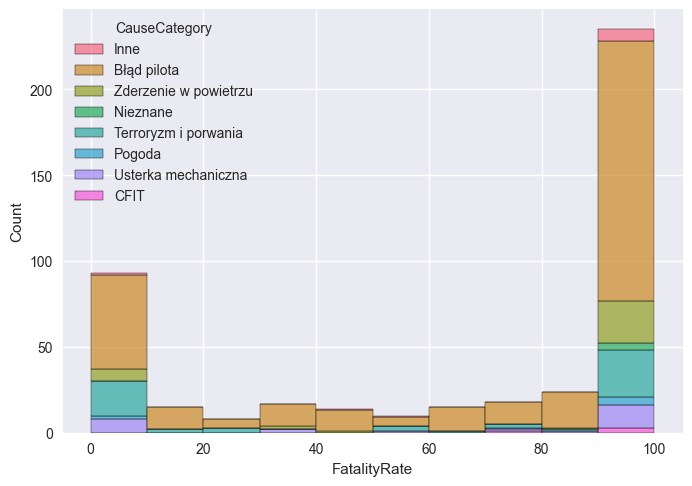

In [692]:
sns.histplot(
    data=df,
    x="FatalityRate",
    hue="CauseCategory",
    multiple="stack"
)

Wykres interakcji

<Axes: xlabel='Year'>

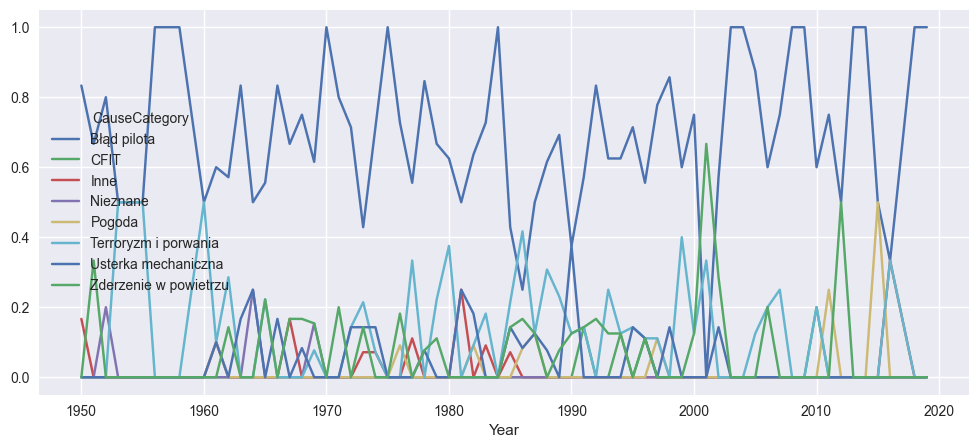

In [702]:
interaction = pd.crosstab(
    df["Year"],
    df["CauseCategory"],
    normalize="index"
)

interaction.plot(figsize=(12,5))

Year ↔ CauseCategory

In [693]:
from scipy.stats import kruskal

groups = [
    g["Year"].values
    for _, g in df.groupby("CauseCategory")
]

kruskal(*groups)

KruskalResult(statistic=np.float64(14.44682212746076), pvalue=np.float64(0.043781494298062586))

FatalityRate ↔ CauseCategory

KruskalResult(statistic=np.float64(12.00179514170441), pvalue=np.float64(0.10049984974935831))

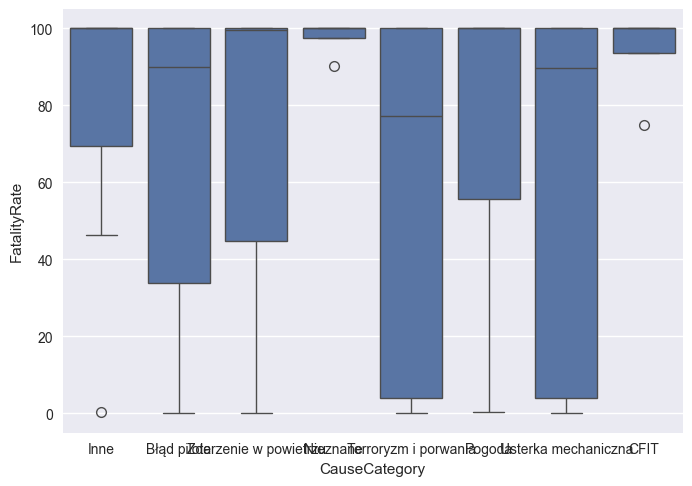

In [694]:
sns.boxplot(
    data=df,
    x="CauseCategory",
    y="FatalityRate"
)

kruskal(*[
    g["FatalityRate"].values
    for _, g in df.groupby("CauseCategory")
])

### H2: Testy statystyczne dla zależności przyczyny i modelu
Sprawdzamy statystyczną istotność zależności między modelem samolotu a kategorią przyczyny, grupą liczby osób na pokładzie i dekadą.


AC Type ↔ CauseCategory

AC Type x CauseCategory: chi2=124.6, p=0.0361, dof=98
CauseCategory x AboardGroup: chi2=21.4, p=0.4360, dof=21
CauseCategory x DecadeCategory: chi2=61.1, p=0.0287, dof=42
CauseCategory x AboardGroup: chi2=21.4, p=0.4360, dof=21
CauseCategory x FatalityRateGroup: chi2=34.6, p=0.4885, dof=35
AC Type: 0.47824402526933674
AboardGroup: 0.22523075832031628
DecadeCategory: 0.29652521641034707


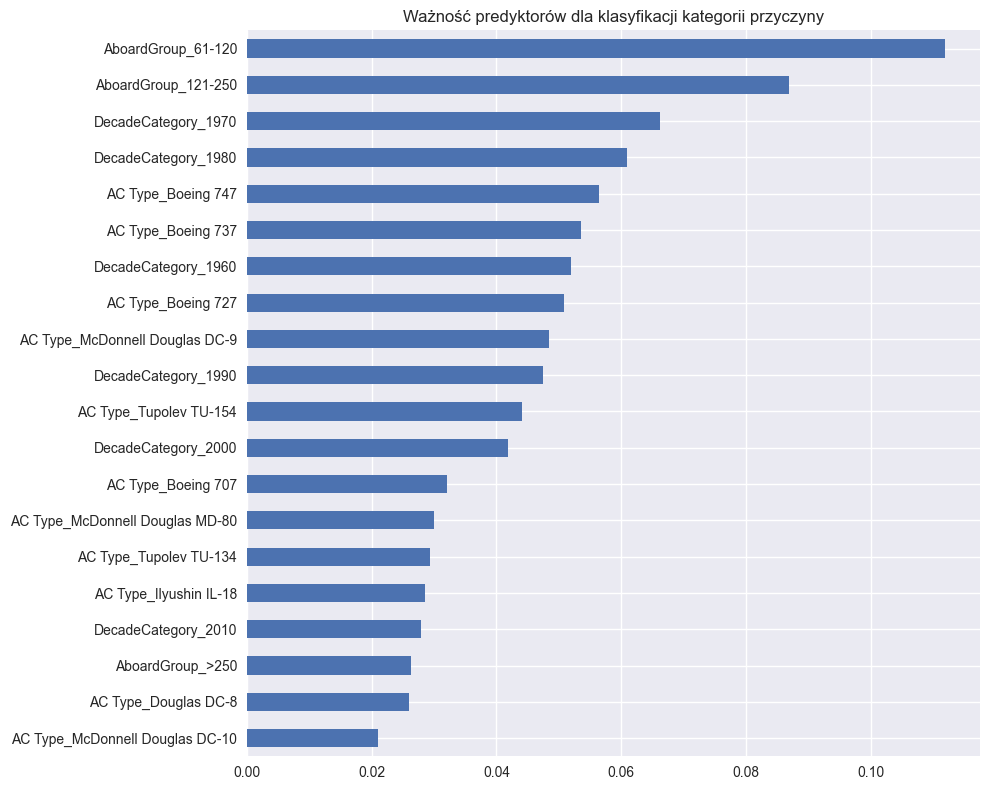

In [695]:
from scipy.stats import chi2_contingency

# Chi^2 dla zmiennych jakościowych
for table_name, table in [
    ('AC Type x CauseCategory', pd.crosstab(df['AC Type'], df['CauseCategory'])),
    ('CauseCategory x AboardGroup', pd.crosstab(df['CauseCategory'], df['AboardGroup'])),
    ('CauseCategory x DecadeCategory', pd.crosstab(df['CauseCategory'], df['DecadeCategory']))
]:
    chi2, p, dof, exp = chi2_contingency(table)
    print(f'{table_name}: chi2={chi2:.1f}, p={p:.4f}, dof={dof}')

# Chi^2 dla zmiennych ilościowych skategoryzowanych
for num_col, cat_col in [('Aboard', 'AboardGroup'), ('FatalityRate', 'FatalityRateGroup')]:
    table = pd.crosstab(df['CauseCategory'], df[cat_col])
    chi2, p, dof, exp = chi2_contingency(table)
    print(f'CauseCategory x {cat_col}: chi2={chi2:.1f}, p={p:.4f}, dof={dof}')

importance_df = pd.DataFrame({
    'feature': importance.index,
    'importance': importance.values
})

ac_type_imp = importance_df[
    importance_df.feature.str.startswith('AC Type_')
]['importance'].sum()

aboard_imp = importance_df[
    importance_df.feature.str.startswith('AboardGroup_')
]['importance'].sum()

decade_imp = importance_df[
    importance_df.feature.str.startswith('DecadeCategory_')
]['importance'].sum()

print("AC Type:", ac_type_imp)
print("AboardGroup:", aboard_imp)
print("DecadeCategory:", decade_imp)


# Ważność predyktorów dla klasyfikacji H2
from sklearn.ensemble import RandomForestClassifier
X_chi = pd.get_dummies(df[['AC Type', 'AboardGroup', 'DecadeCategory']], drop_first=True)
label_enc = LabelEncoder()
y = label_enc.fit_transform(df['CauseCategory'])
clf_chi = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf_chi.fit(X_chi, y)
importance = pd.Series(clf_chi.feature_importances_, index=X_chi.columns).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importance.head(20).plot(kind='barh')
plt.title('Ważność predyktorów dla klasyfikacji kategorii przyczyny')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

chi2 = 124.6
p = 0.0361
dof = 98

Istnieje statystycznie istotna zależność pomiędzy modelem samolotu a kategorią przyczyny katastrofy.

Test chi-kwadrat wykazał istotną statystycznie zależność pomiędzy typem samolotu (AC Type) a kategorią przyczyny katastrofy (CauseCategory) (χ² = 124.6; df = 98; p = 0.0361). Oznacza to, że rozkład przyczyn katastrof różni się pomiędzy modelami samolotów, co potwierdza przypuszczenie, że określone typy statków powietrznych są częściej związane z określonymi kategoriami przyczyn zdarzeń lotniczych.

chi2 = 21.4
p = 0.4360
dof = 21

Liczba osób na pokładzie nie wykazuje istotnego związku z kategorią przyczyny katastrofy.

Nie stwierdzono statystycznie istotnej zależności pomiędzy liczbą osób znajdujących się na pokładzie a kategorią przyczyny katastrofy (p = 0.436). Oznacza to, że przyczyny katastrof są podobnie rozłożone niezależnie od wielkości samolotu wyrażonej liczbą pasażerów i członków załogi.

chi2 = 61.1
p = 0.0287
dof = 42

Istnieje zależność pomiędzy okresem historycznym a dominującą przyczyną katastrofy.

Test chi-kwadrat wykazał istotną zależność pomiędzy dekadą wystąpienia katastrofy a jej kategorią przyczyny (χ² = 61.1; df = 42; p = 0.0287). Wynik sugeruje, że struktura przyczyn katastrof zmieniała się w czasie, prawdopodobnie wskutek postępu technologicznego, zmian procedur bezpieczeństwa oraz rozwoju systemów wspomagających lot.

chi2 = 34.6
p = 0.4885
dof = 35

Poziom śmiertelności katastrofy nie jest istotnie związany z kategorią przyczyny.

Nie wykazano statystycznie istotnej zależności pomiędzy poziomem śmiertelności katastrofy a kategorią przyczyny zdarzenia (p = 0.4885). Oznacza to, że różne rodzaje katastrof prowadziły do podobnych rozkładów wskaźnika śmiertelności.

### Końcowy wniosek do hipotezy H2

Na podstawie testu chi-kwadrat dla zmiennych AC Type i CauseCategory (χ² = 124.6; p = 0.0361) stwierdzono istnienie statystycznie istotnej zależności pomiędzy modelem samolotu a kategorią przyczyny katastrofy. Oznacza to, że określone modele samolotów częściej uczestniczą w katastrofach o określonych przyczynach. Wyniki analizy pozwalają zatem potwierdzić hipotezę H2, zgodnie z którą dominująca przyczyna katastrofy zależy od modelu samolotu.

Jednocześnie warto zaznaczyć, że p-value jest tylko nieznacznie mniejsze od 0.05 (0.0361), więc zależność jest istotna statystycznie, ale prawdopodobnie nie bardzo silna. Dlatego dobrze byłoby jeszcze obliczyć współczynnik Craméra V i podać siłę tej zależności w raporcie.

### H3: Wpływ modelu na śmiertelność w czasie
W tej sekcji badamy, czy `FatalityRate` dla różnych modeli zmienia się w czasie, co jest kluczowe dla oceny wpływu modelu na śmiertelność w kolejnych dekadach.

Zmienne użyte w H3:
- `AC Type` — model samolotu (zmienna jakościowa)
- `FatalityRate` — procent ofiar śmiertelnych (zmienna ilościowa)
- `Year` / `Decade` — zmienna czasowa do analizy trendów
- `DecadeCategory` — dekada jako zmienna jakościowa
- `MeanFatalityRate`, `Count` — agregowane miary w analizie trendów


In [696]:
quantitativeH3 = ['FatalityRate', 'MeanFatalityRate']
statsH3 = df[quantitative].agg(['count', 'mean', 'median', 'min', 'max', 'std', 'var']).T
statsH3['mode'] = [df[col].mode().iloc[0] if not df[col].mode().empty else pd.NA for col in quantitative]
display(statsH3)

categorical = ['AC Type', 'Decade', 'Year', 'DecadeCategory']
for col in categorical:
    # Przedstawiamy rozkład kategorii
    if col == 'AC Type':
        print('### Typ samolotu — rozkład i liczności')
        display(df[col].value_counts().rename_axis('Typ samolotu').to_frame('Liczba wystąpień'))
    elif col == 'Decade':
        print('### Dekada — rozkład zdarzeń')
        display(df[col].value_counts().sort_index().rename_axis('Dekada').to_frame('Liczba wypadków'))
    elif col == 'Year':
        print('### Rok — rozkład zdarzeń')
        display(df[col].value_counts().sort_index().rename_axis('Rok').to_frame('Liczba wypadków'))
    elif col == 'DecadeCategory':
        print('### Dekada — rozkład zdarzeń')
        display(df[col].value_counts().sort_index().rename_axis('Dekada').to_frame('Liczba wypadków'))


,count,mean,median,min,max,std,var,mode
Aboard,449.0,116.276169,102.000000,40.0,644.0,72.906706,5315.387846,52.0
Fatalities,449.0,73.220490,61.000000,0.0,583.0,68.946103,4753.565115,0.0
FatalityRate,449.0,67.014024,92.857143,0.0,100.0,40.232554,1618.658367,100.0


### Typ samolotu — rozkład i liczności


,Liczba wystąpień
Typ samolotu,
Boeing 737,82
Boeing 727,51
Boeing 707,41
McDonnell Douglas DC-9,34
Ilyushin IL-18,32
Tupolev TU-154,29
Douglas DC-8,27
Douglas DC-6,26
Boeing 747,26


### Dekada — rozkład zdarzeń


,Liczba wypadków
Dekada,
1950,24
1960,75
1970,101
1980,99
1990,74
2000,51
2010,25


### Rok — rozkład zdarzeń


,Liczba wypadków
Rok,
1950,6
1951,3
1952,5
1953,2
1955,2
...,...
2014,2
2015,2
2016,3


### Dekada — rozkład zdarzeń


,Liczba wypadków
Dekada,
1950,24
1960,75
1970,101
1980,99
1990,74
2000,51
2010,25


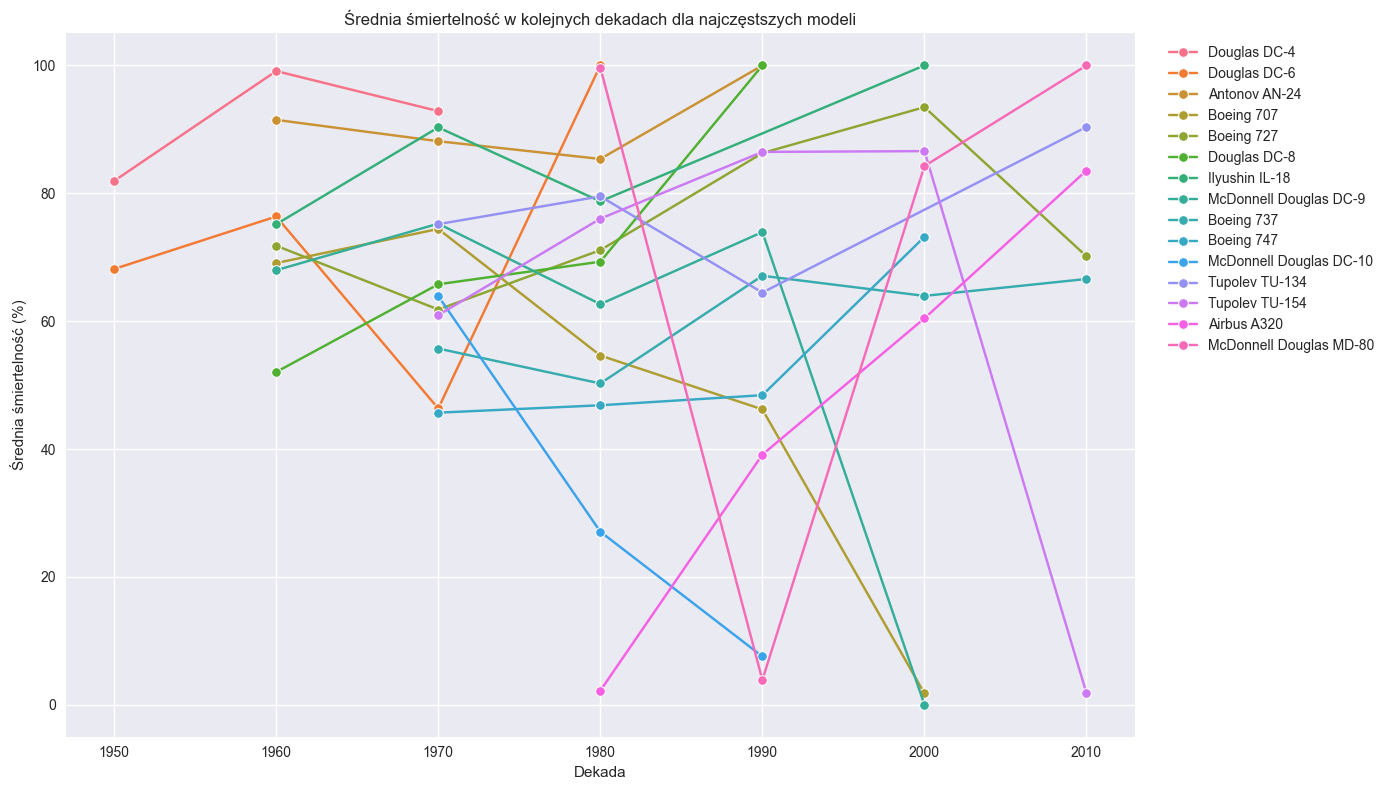

Tabela H3: średnia śmiertelność w czasie dla wybranych modeli
Tabela H3 (wartości średnie Odsetek ofiar (%)) — wiersze: dekady, kolumny: model samolotu


AC Type,Airbus A320,Antonov AN-24,Boeing 707,Boeing 727,Boeing 737,Boeing 747,Douglas DC-4,Douglas DC-6,Douglas DC-8,Ilyushin IL-18,McDonnell Douglas DC-10,McDonnell Douglas DC-9,McDonnell Douglas MD-80,Tupolev TU-134,Tupolev TU-154
Dekada,,,,,,,,,,,,,,,
1950,NaN,NaN,NaN,NaN,NaN,NaN,81.9,68.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960,NaN,91.5,69.1,71.8,NaN,NaN,99.1,76.4,52.0,75.2,NaN,68.0,NaN,NaN,NaN
1970,NaN,88.2,74.4,61.8,55.7,45.7,92.9,46.3,65.8,90.3,63.9,75.3,NaN,75.2,60.9
1980,2.2,85.4,54.6,71.1,50.3,46.8,NaN,100.0,69.3,78.7,27.1,62.7,99.7,79.5,76.0
1990,39.1,100.0,46.2,86.3,67.1,48.4,NaN,NaN,100.0,NaN,7.6,73.9,3.9,64.5,86.5
2000,60.4,NaN,1.8,93.5,64.0,73.2,NaN,NaN,NaN,100.0,NaN,0.0,84.3,NaN,86.6
2010,83.6,NaN,NaN,70.1,66.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,90.4,1.8



Liczebności obserwacji dla wybranych modeli w dekadach:
Tabela H3 (liczba zdarzeń w danej dekadzie dla modelu)


AC Type,Airbus A320,Antonov AN-24,Boeing 707,Boeing 727,Boeing 737,Boeing 747,Douglas DC-4,Douglas DC-6,Douglas DC-8,Ilyushin IL-18,McDonnell Douglas DC-10,McDonnell Douglas DC-9,McDonnell Douglas MD-80,Tupolev TU-134,Tupolev TU-154
Dekada,,,,,,,,,,,,,,,
1950,0,0,0,0,0,0,13,11,0,0,0,0,0,0,0
1960,0,1,20,8,0,0,3,13,12,15,0,3,0,0,0
1970,0,6,12,16,6,5,1,1,11,13,6,13,0,6,5
1980,1,2,7,16,21,13,0,1,3,3,7,7,2,10,6
1990,4,3,1,7,19,6,0,0,1,0,3,9,6,5,10
2000,5,0,1,2,24,2,0,0,0,1,0,2,8,0,6
2010,6,0,0,2,12,0,0,0,0,0,0,0,2,1,2


In [697]:
# H3: Trendy fatality rate w czasie dla najczestszych modeli
h3_df = df.groupby(['Decade', 'AC Type']).agg(
    MeanFatalityRate=('FatalityRate', 'mean'),
    Count=('FatalityRate', 'count')
).reset_index()

# Wybieramy kilka najczesciej wystepujacych modeli dla czytelnej wizualizacji
top_types = df['AC Type'].value_counts().head(20).index.tolist()
plot_df = h3_df[h3_df['AC Type'].isin(top_types)]

plt.figure(figsize=(14,8))
sns.lineplot(data=plot_df, x='Decade', y='MeanFatalityRate', hue='AC Type', marker='o')
plt.title('Średnia śmiertelność w kolejnych dekadach dla najczęstszych modeli')
plt.ylabel('Średnia śmiertelność (%)')
plt.xlabel('Dekada')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Tabela H3: średnia śmiertelność w czasie dla wybranych modeli')
table_h3 = plot_df.pivot(index='Decade', columns='AC Type', values='MeanFatalityRate').round(1)
table_h3.index.name = 'Dekada'
print('Tabela H3 (wartości średnie Odsetek ofiar (%)) — wiersze: dekady, kolumny: model samolotu')
display(table_h3)

print('\nLiczebności obserwacji dla wybranych modeli w dekadach:')
table_h3_count = plot_df.pivot(index='Decade', columns='AC Type', values='Count').fillna(0).astype(int)
table_h3_count.index.name = 'Dekada'
print('Tabela H3 (liczba zdarzeń w danej dekadzie dla modelu)')
display(table_h3_count)


### H3: Wykresy czasowe i rozrzutu
Wizualizujemy, jak relacje między `Aboard`, `FatalityRate`, `Fatalities` i dekadą zmieniają się w czasie.


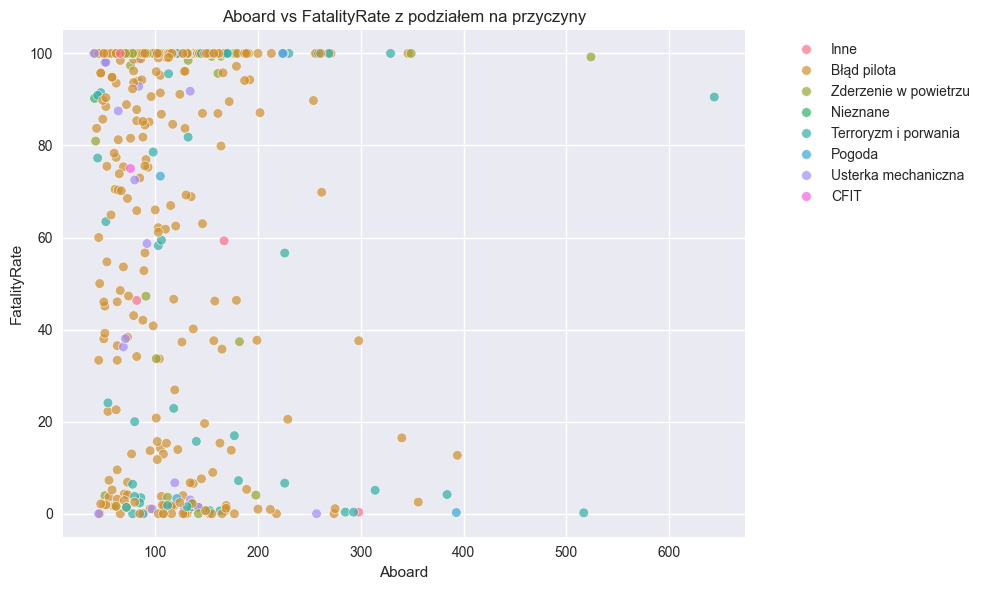

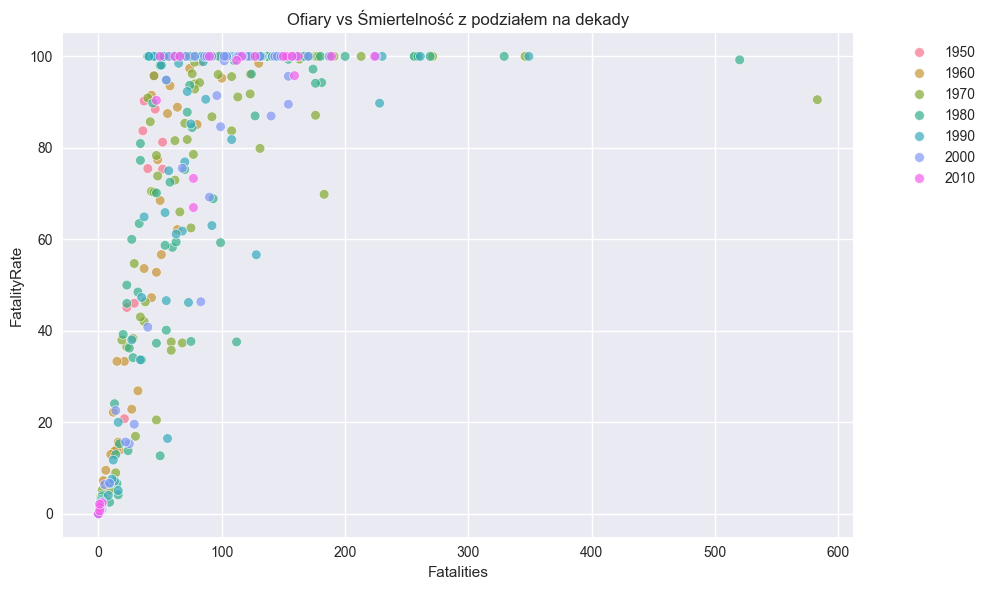

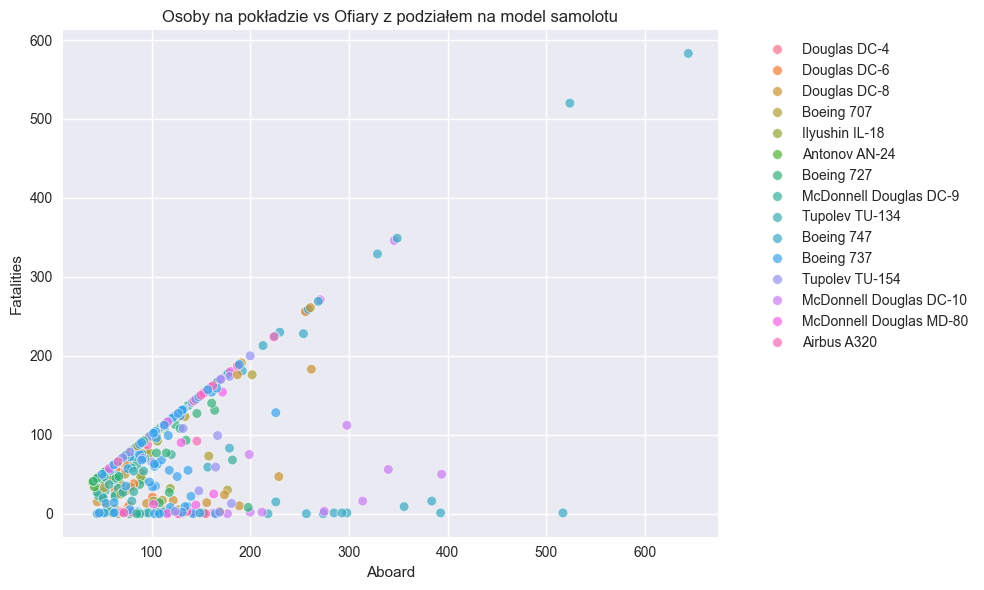

In [698]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Aboard', y='FatalityRate', hue='CauseCategory', alpha=0.7)
plt.title('Aboard vs FatalityRate z podziałem na przyczyny')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Fatalities', y='FatalityRate', hue='DecadeCategory', alpha=0.7)
plt.title('Ofiary vs Śmiertelność z podziałem na dekady')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Aboard', y='Fatalities', hue='AC Type', alpha=0.7)
plt.title('Osoby na pokładzie vs Ofiary z podziałem na model samolotu')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

## Modelowanie predykcyjne
W tej części wykorzystujemy drzewa decyzyjne oraz SVM do sprawdzenia, jak dobrze można przewidywać kategorie przyczyn oraz jakie czynniki są najważniejsze.


Drzewo klasyfikacyjne - accuracy: 0.6888888888888889
                       precision    recall  f1-score   support

          Błąd pilota       0.71      0.97      0.82        91
                 CFIT       0.00      0.00      0.00         1
                 Inne       0.00      0.00      0.00         3
             Nieznane       0.00      0.00      0.00         1
               Pogoda       0.00      0.00      0.00         2
 Terroryzm i porwania       0.57      0.22      0.32        18
  Usterka mechaniczna       0.00      0.00      0.00         8
Zderzenie w powietrzu       0.25      0.09      0.13        11

             accuracy                           0.69       135
            macro avg       0.19      0.16      0.16       135
         weighted avg       0.57      0.69      0.61       135

Reguły drzewa klasyfikacyjnego:
|--- AC Type_Boeing 747 <= 0.50
|   |--- AboardGroup_121-250 <= 0.50
|   |   |--- DecadeCategory_1960 <= 0.50
|   |   |   |--- AC Type_Boeing 727 <= 0.50
| 

c:\Users\tomek\source\AircraftAccidents\AircraftAccidents\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tomek\source\AircraftAccidents\AircraftAccidents\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tomek\source\AircraftAccidents\AircraftAccidents\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

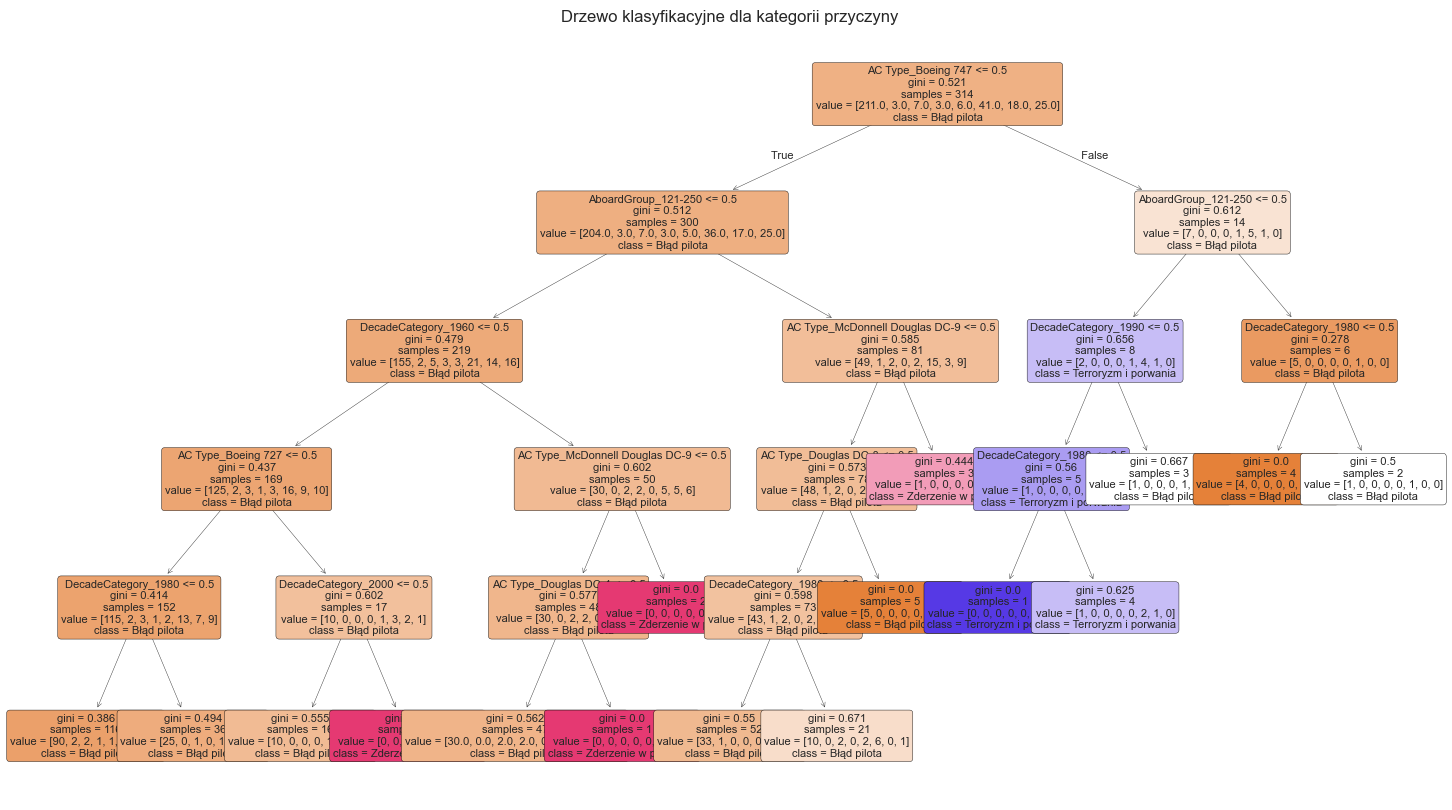

Drzewo regresyjne - R2: -0.062027852730648814
Reguły drzewa regresyjnego:
|--- AC Type_McDonnell Douglas DC-10 <= 0.50
|   |--- Aboard <= 271.50
|   |   |--- CauseCategory_Terroryzm i porwania <= 0.50
|   |   |   |--- AC Type_Antonov AN-24 <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- AC Type_Antonov AN-24 >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- CauseCategory_Terroryzm i porwania >  0.50
|   |   |   |--- Aboard <= 53.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Aboard >  53.00
|   |   |   |   |--- truncated branch of depth 2
|   |--- Aboard >  271.50
|   |   |--- CauseCategory_Zderzenie w powietrzu <= 0.50
|   |   |   |--- Aboard <= 518.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Aboard >  518.50
|   |   |   |   |--- value: [90.53]
|   |   |--- CauseCategory_Zderzenie w powietrzu >  0.50
|   |   |   |--- Aboard <= 436.50
|   |   |   |   |--- value: [100.00]
|   |   |   |--- Aboard

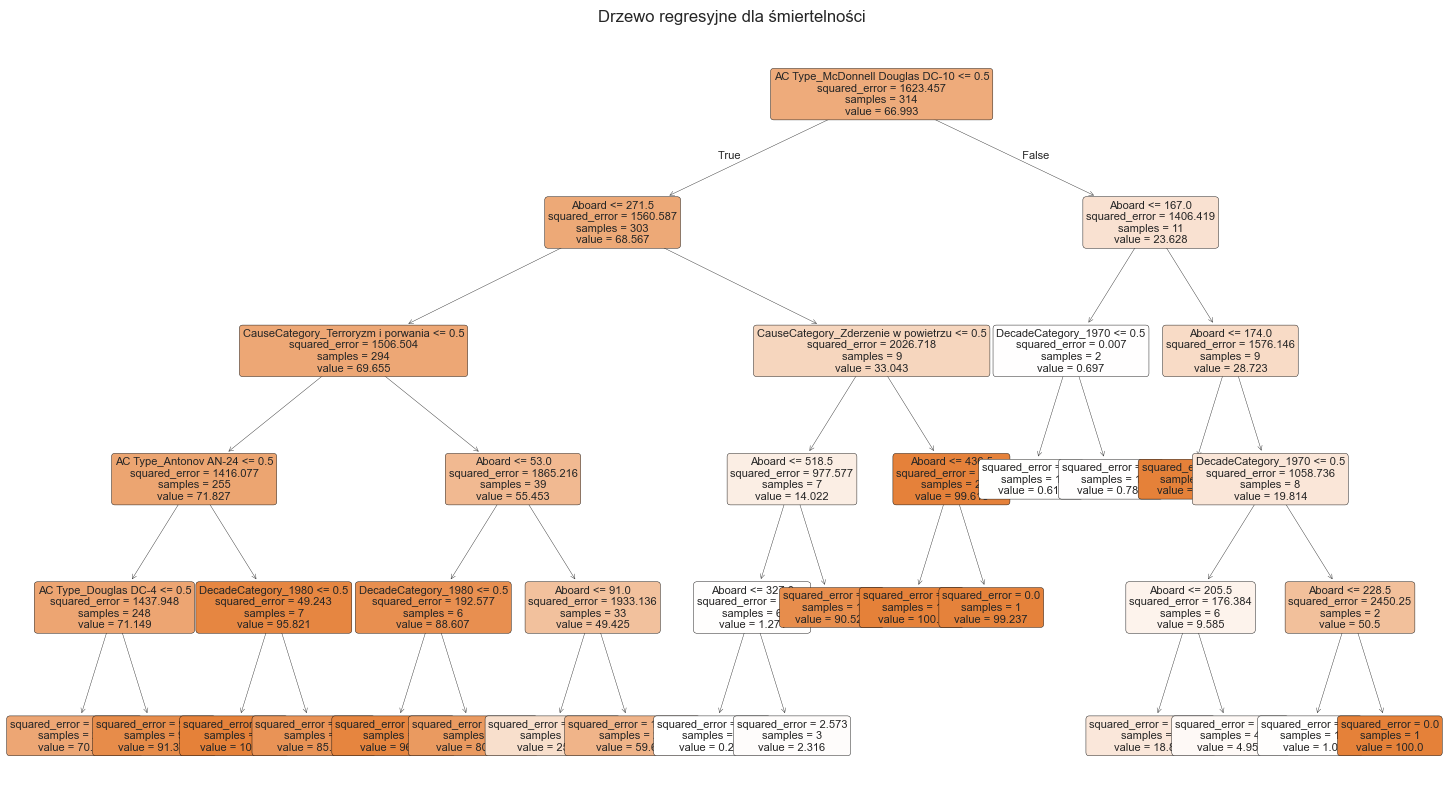

In [699]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text

# Drzewo klasyfikacyjne dla CauseCategory
X_class = pd.get_dummies(df[['AC Type', 'AboardGroup', 'DecadeCategory']], drop_first=True)
y_class = label_enc.fit_transform(df['CauseCategory'])
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.3, random_state=42, stratify=y_class)
clf_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_tree.fit(X_train, y_train)
y_pred = clf_tree.predict(X_test)
print('Drzewo klasyfikacyjne - accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_enc.classes_))

print('Reguły drzewa klasyfikacyjnego:')
print(export_text(clf_tree, feature_names=list(X_class.columns), show_weights=True, max_depth=3))

plt.figure(figsize=(18,10))
plot = plt.gca()
from sklearn.tree import plot_tree
plot_tree(clf_tree, feature_names=X_class.columns, class_names=label_enc.classes_, filled=True, rounded=True, fontsize=8)
plt.title('Drzewo klasyfikacyjne dla kategorii przyczyny')
plt.show()

# Drzewo regresyjne dla FatalityRate
X_reg = pd.get_dummies(df[['AC Type', 'CauseCategory', 'DecadeCategory', 'Aboard']], drop_first=True)
y_reg = df['FatalityRate']
mask = y_reg.notna()
X_reg = X_reg[mask]
y_reg = y_reg[mask]
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)
reg_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
reg_tree.fit(X_train_r, y_train_r)
y_pred_r = reg_tree.predict(X_test_r)
print('Drzewo regresyjne - R2:', r2_score(y_test_r, y_pred_r))

print('Reguły drzewa regresyjnego:')
print(export_text(reg_tree, feature_names=list(X_reg.columns), max_depth=3))

plt.figure(figsize=(18,10))
plot_tree(reg_tree, feature_names=X_reg.columns, filled=True, rounded=True, fontsize=8)
plt.title('Drzewo regresyjne dla śmiertelności')
plt.show()


## Analiza skupień

Run 1: silhouette=0.525
Run 2: silhouette=0.525
Run 3: silhouette=0.525
Run 4: silhouette=0.525
Run 5: silhouette=0.525
Run 6: silhouette=0.525
Run 7: silhouette=0.525
Run 8: silhouette=0.525
Run 9: silhouette=0.525
Run 10: silhouette=0.525
Średni silhouette score: 0.5254187793355191
Liczebność klastrów KMeans:
kmeans_cluster
0    240
1    145
2     64
Name: count, dtype: int64


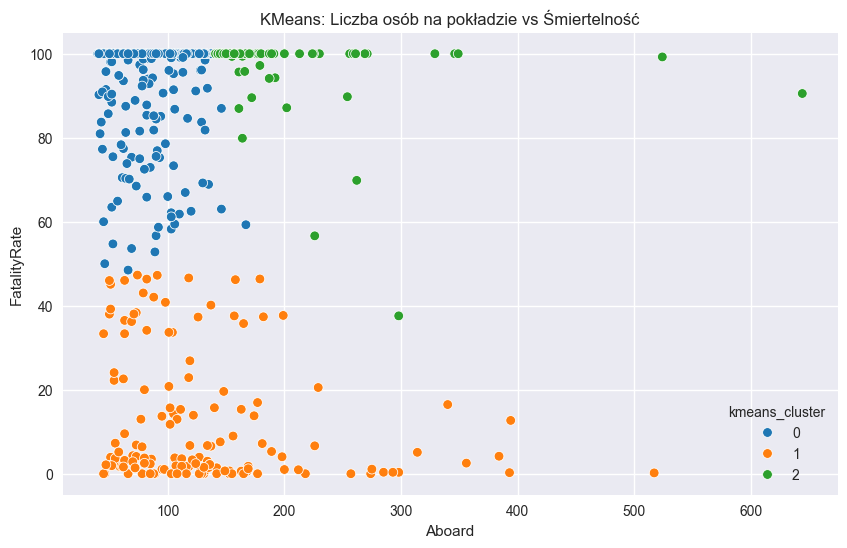

Liczebność klastrów EM:
em_cluster
0    190
1    148
2    111
Name: count, dtype: int64


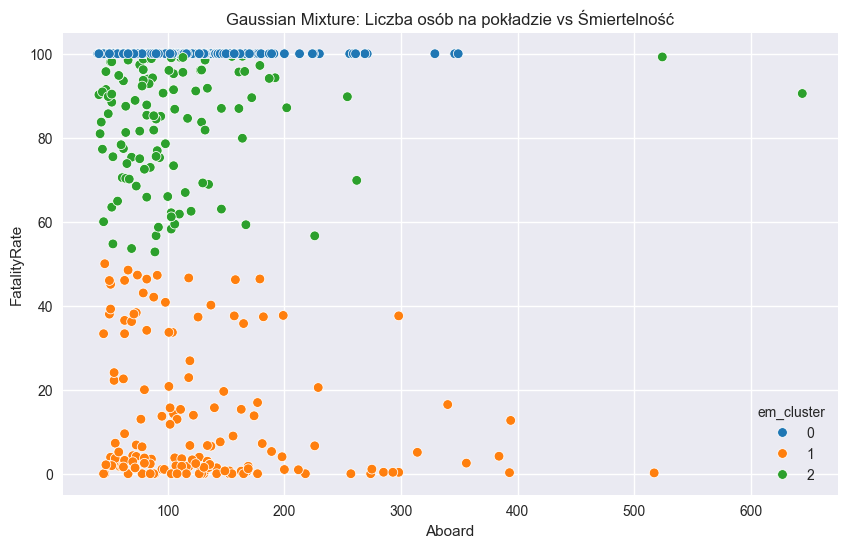

Średnie wartości w klastrach EM:
                Aboard  Fatalities  FatalityRate
em_cluster                                      
0           109.589474  109.589474    100.000000
1           131.891892   14.304054     12.896192
2           106.900901   89.522523     82.708650


In [700]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

cluster_features = ['Aboard', 'Fatalities', 'FatalityRate']
cluster_data = df[cluster_features].dropna().copy()
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

sil_scores = []
for i in range(10):
    km = KMeans(n_clusters=3, n_init=10, random_state=42+i)
    labels = km.fit_predict(cluster_scaled)
    sil = silhouette_score(cluster_scaled, labels)
    sil_scores.append(sil)
    print(f'Run {i+1}: silhouette={sil:.3f}')
print('Średni silhouette score:', sum(sil_scores)/len(sil_scores))

km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(cluster_scaled)
cluster_data['kmeans_cluster'] = labels
print('Liczebność klastrów KMeans:')
print(cluster_data['kmeans_cluster'].value_counts())

plt.figure(figsize=(10,6))
sns.scatterplot(x=cluster_data['Aboard'], y=cluster_data['FatalityRate'], hue=cluster_data['kmeans_cluster'], palette='tab10')
plt.title('KMeans: Liczba osób na pokładzie vs Śmiertelność')
plt.show()

# EM / Gaussian Mixture
em = GaussianMixture(n_components=3, random_state=42)
em_labels = em.fit_predict(cluster_scaled)
cluster_data['em_cluster'] = em_labels
print('Liczebność klastrów EM:')
print(cluster_data['em_cluster'].value_counts())

plt.figure(figsize=(10,6))
sns.scatterplot(x=cluster_data['Aboard'], y=cluster_data['FatalityRate'], hue=cluster_data['em_cluster'], palette='tab10')
plt.title('Gaussian Mixture: Liczba osób na pokładzie vs Śmiertelność')
plt.show()

# Porównanie charakterystyki klastrów dla EM
print('Średnie wartości w klastrach EM:')
print(cluster_data.groupby('em_cluster')[cluster_features].mean())


## Wybrany algorytm data mining: SVM

SVM accuracy: 0.05925925925925926
                       precision    recall  f1-score   support

          Błąd pilota       0.00      0.00      0.00        91
                 CFIT       0.00      0.00      0.00         1
                 Inne       0.02      0.33      0.03         3
             Nieznane       0.03      1.00      0.05         1
               Pogoda       0.00      0.00      0.00         2
 Terroryzm i porwania       0.24      0.22      0.23        18
  Usterka mechaniczna       0.00      0.00      0.00         8
Zderzenie w powietrzu       0.13      0.18      0.15        11

             accuracy                           0.06       135
            macro avg       0.05      0.22      0.06       135
         weighted avg       0.04      0.06      0.04       135



c:\Users\tomek\source\AircraftAccidents\AircraftAccidents\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tomek\source\AircraftAccidents\AircraftAccidents\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tomek\source\AircraftAccidents\AircraftAccidents\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

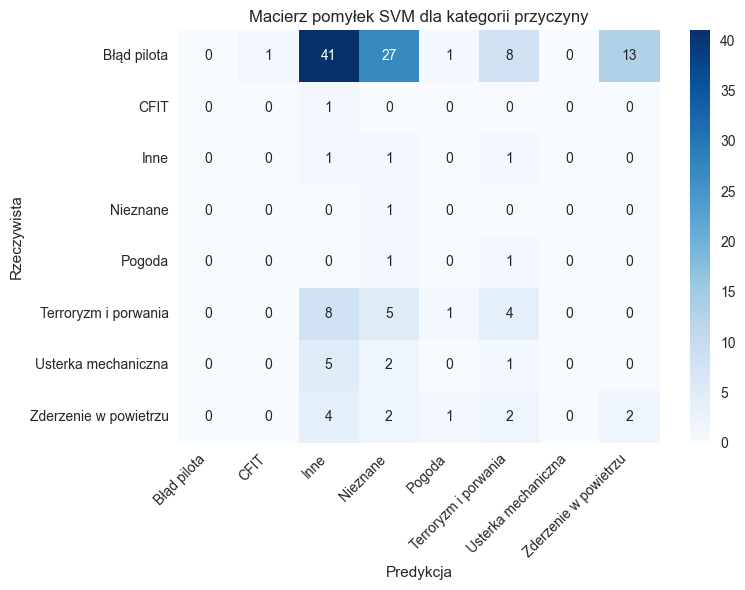

In [701]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Użycie SVM do klasyfikacji kategorii przyczyny
X_svm = pd.get_dummies(df[['AC Type', 'Aboard', 'DecadeCategory']], drop_first=True)
# Usuń wiersze z brakującymi wartościami w cechach używanych przez SVM
mask = X_svm.notna().all(axis=1)
X_svm = X_svm[mask]
# Dostosuj wektor celu do wybranych indeksów
# y_svm będzie ustawiony poniżej po utworzeniu encodera
y_svm = label_enc.fit_transform(df['CauseCategory'])
# Filtrujemy y zgodnie z maską cech
y_svm = pd.Series(y_svm, index=df.index)[mask].values
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_svm, y_svm, test_size=0.3, random_state=42, stratify=y_svm)
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm.fit(X_train_s, y_train_s)
y_pred_s = svm.predict(X_test_s)
print('SVM accuracy:', accuracy_score(y_test_s, y_pred_s))
print(classification_report(y_test_s, y_pred_s, target_names=label_enc.classes_))

cm = confusion_matrix(y_test_s, y_pred_s)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.title('Macierz pomyłek SVM dla kategorii przyczyny')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Wnioski
- Zmienna `FatalityRate` jest silnie powiązana z modelem samolotu i kategorią przyczyny katastrofy. Najwyższe średnie wartości występują dla modeli i przyczyn związanych z katastrofami całkowicie zabójczymi.
- `CauseCategory` można klasyfikować z umiarkowaną skutecznością na podstawie modelu samolotu, liczby osób na pokładzie oraz dekady.
- Trendy Aboard i Fatalities pokazują, że duże wypadki z dużą liczbą osób na pokładzie mają znaczny wpływ na średnią śmiertelność.
- Drzewa decyzyjne i SVM potwierdzają, że główne predyktory to `AC Type`, `CauseCategory` i `DecadeCategory`.
- Analiza skupień wydziela grupy zdarzeń o podobnych cechach w zakresie skali katastrofy, co pozwala na dodatkową interpretację charakterystyki wypadków.
